In [1]:
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/development/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers_mod as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

In [4]:
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
vlf_files = list(glob.glob('./drive/MyDrive/Distributions/VLF/qq2ttbar_gs4_ydm2/mass_scan/*.npz')) + list(glob.glob('./drive/MyDrive/Distributions/VLF/gg2ttbar_gs4_ydm2/mass_scan/*.npz'))
scalar_files = list(glob.glob('./drive/MyDrive/Distributions//Scalar/qq2ttbar_gs4_ydm2/mass_scan/*.npz')) + list(glob.glob('./drive/MyDrive/Distributions/Scalar/gg2ttbar_gs4_ydm2/mass_scan/*.npz'))
zp_files = list(glob.glob('./drive/MyDrive/Distributions/Zprime/mass_scan/*.npz'))
sm_files = list(glob.glob('./drive/MyDrive/Distributions/SM/pp2ttbar/bias_article*/*.npz'))
fake_data_files = list(glob.glob('./drive/MyDrive/Distributions//Scalar/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz')) + list(glob.glob('./drive/MyDrive/Distributions/Scalar/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz'))

print("--- File Discovery Check ---")
print(f"VLF files found:       {len(vlf_files)}")
print(f"Scalar files found:    {len(scalar_files)}")
print(f"Zprime files found:    {len(zp_files)}")
print(f"Fake data files found: {len(fake_data_files)}")
print(f"SM files found:        {len(sm_files)}\n")

target_xsec = 0.03445610687471812 / 1.3
lumi = 500.0
sys_err = 0.05
target_yield = target_xsec * lumi * 1000.0

# Bins and Masks
bins = np.arange(1500., 4600., 100.)
mass_mask = (bins[:-1] >= 1500) & (bins[:-1] <= 4500)
valid_bin_centers = (bins[:-1] + np.diff(bins)/2)[mass_mask]

# ============================================================
# Build Baselines (Fake Data & SM)
# ============================================================
n_fake = np.zeros(len(bins)-1, dtype=np.float64)
for f in fake_data_files:
    d = np.load(f, allow_pickle=True)
    h_fake, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    n_fake += h_fake * lumi * 1000.0

# 1. Normalize fake data inside the mass mask FIRST
factor = np.float64(target_yield) / np.sum(n_fake[mass_mask], dtype=np.float64)
n_fake = n_fake * factor

target_fake_yield = np.sum(n_fake[mass_mask], dtype=np.float64)
print(f"Fake Data correctly normalized to yield: {target_fake_yield:.2f} events in target window.")

n_sm = np.zeros(len(bins)-1, dtype=np.float64)
for f in sm_files:
    d = np.load(f, allow_pickle=True)
    h_sm, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    n_sm += h_sm * lumi * 1000.0
n_sm = n_sm / len(sm_files)

# Pre-calculate the variance denominator for the chi2
chi2_denom_full = (n_fake + n_sm) + (sys_err * n_sm)**2
chi2_denom_masked = chi2_denom_full[mass_mask]

# ============================================================
# Mass Scan (VLF and Scalar)
# ============================================================
masses = [1000.0]

results = {'masses': masses, 'VLF': [], 'Scalar': [], 'Zprime': []}
chi2_min = {'VLF': (masses[0], 1e+9, 0.), 'Scalar': (masses[0], 1e+9, 0.), 'Zprime': (1000.0, 1e+9, 0.),
            'FakeData': factor}

history = {
    'bin_centers': valid_bin_centers,
    'denominator': chi2_denom_masked,
    'VLF': {}, 'Scalar': {}, 'Zprime': {},
    'scale_factors': {'VLF': {}, 'Scalar': {}, 'Zprime': {}} # <-- Added Scale Factors Tracker
}

for m in masses:
    ydm_vlf_sq = np.float64(0.0)
    ydm_scalar_sq = np.float64(0.0)

    vlf_scan = glob.glob(f'./drive/MyDrive/Distributions/VLF/*/mass_scan/mPsiT_{m:.0f}_mSDM_{(m-100.):.0f}.npz')
    scalar_scan = glob.glob(f'./drive/MyDrive/Distributions/Scalar/*/mass_scan/mPsiT_{m:.0f}_mSDM_{(m-100.):.0f}.npz')

    n_vlf = np.zeros(len(bins)-1, dtype=np.float64)
    n_scalar = np.zeros(len(bins)-1, dtype=np.float64)

    for f in vlf_scan:
        d = np.load(f, allow_pickle=True)
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        n_vlf += h * lumi * 1000.0

    for f in scalar_scan:
        d = np.load(f, allow_pickle=True)
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        n_scalar += h * lumi * 1000.0

    valid_vlf, valid_scalar = False, False

    # Normalization (VLF)
    sum_vlf = np.sum(n_vlf[mass_mask], dtype=np.float64)
    if sum_vlf > 0.0:
        ydm_vlf_sq = np.float64(target_fake_yield) / sum_vlf
        if np.sqrt(ydm_vlf_sq, dtype=np.float64) <= 4.0 * np.pi:
            n_vlf = n_vlf * ydm_vlf_sq
            valid_vlf = True

    # Normalization (Scalar)
    sum_scalar = np.sum(n_scalar[mass_mask], dtype=np.float64)
    if sum_scalar > 0.0:
        ydm_scalar_sq = np.float64(target_fake_yield) / sum_scalar
        if np.sqrt(ydm_scalar_sq, dtype=np.float64) <= 4.0 * np.pi:
            n_scalar = n_scalar * ydm_scalar_sq
            valid_scalar = True

    # Calculate and Store (VLF)
    if valid_vlf:
        num_vlf = ((n_vlf - n_fake)**2)[mass_mask]
        history['VLF'][m] = num_vlf
        history['scale_factors']['VLF'][m] = np.sqrt(ydm_vlf_sq, dtype=np.float64) # <-- Saved

        chi2_vlf = np.sum(num_vlf / chi2_denom_masked, dtype=np.float64)
        results['VLF'].append(chi2_vlf)
        if chi2_vlf < chi2_min['VLF'][1]:
            chi2_min['VLF'] = (m, chi2_vlf, np.sqrt(ydm_vlf_sq, dtype=np.float64))
    else:
        results['VLF'].append(np.inf)

    # Calculate and Store (Scalar)
    if valid_scalar:
        num_scalar = ((n_scalar - n_fake)**2)[mass_mask]
        history['Scalar'][m] = num_scalar
        history['scale_factors']['Scalar'][m] = np.sqrt(ydm_scalar_sq, dtype=np.float64) # <-- Saved

        chi2_scalar = np.sum(num_scalar / chi2_denom_masked, dtype=np.float64)
        results['Scalar'].append(chi2_scalar)
        if chi2_scalar < chi2_min['Scalar'][1]:
            chi2_min['Scalar'] = (m, chi2_scalar, np.sqrt(ydm_scalar_sq, dtype=np.float64))
    else:
        results['Scalar'].append(np.inf)

# ============================================================
# Mass Scan (Zprime)
# ============================================================
masses_zp = [2000.0]
results['masses_zp'] = masses_zp

for m in masses_zp:
    mu_Zp = np.float64(1.0) # Default fallback
    zp_scan = glob.glob(f'./drive/MyDrive/Distributions/Zprime/mass_scan/mZp_{m:.0f}.npz')
    n_Zp = np.zeros(len(bins)-1, dtype=np.float64)

    for f in zp_scan:
        d = np.load(f, allow_pickle=True)
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        n_Zp += h * lumi * 1000.0

    sum_zp = np.sum(n_Zp[mass_mask], dtype=np.float64)
    if sum_zp > 0.0:
        mu_Zp = np.float64(target_fake_yield) / sum_zp
        n_Zp = n_Zp * mu_Zp

    num_zp = ((n_Zp - n_fake)**2)[mass_mask]

    # Store history and scale factor
    history['Zprime'][m] = num_zp
    history['scale_factors']['Zprime'][m] = mu_Zp # <-- Saved

    chi2_Zp = np.sum(num_zp / chi2_denom_masked, dtype=np.float64)
    results['Zprime'].append(chi2_Zp)

    if chi2_Zp < chi2_min['Zprime'][1]:
        chi2_min['Zprime'] = (m, chi2_Zp, mu_Zp)

print("\n--- Best Fit Results (Mass, Chi^2) ---")
for model, fit in chi2_min.items():
    if model == 'FakeData': continue
    print(f"{model:8}: {fit[0]:.0f} GeV , Scale: {fit[2]:.6e} (Chi^2 = {fit[1]:.2f})")

--- File Discovery Check ---
VLF files found:       43
Scalar files found:    42
Zprime files found:    41
Fake data files found: 2
SM files found:        8

Fake Data correctly normalized to yield: 13252.35 events in target window.

--- Best Fit Results (Mass, Chi^2) ---
VLF     : 1000 GeV , Scale: 5.308518e+00 (Chi^2 = 15.56)
Scalar  : 1000 GeV , Scale: 1.111869e+01 (Chi^2 = 0.01)
Zprime  : 2000 GeV , Scale: 9.010605e-01 (Chi^2 = 35.64)


In [5]:
# ------------------------------------------------------------
# Automated Configuration (Using Best Fits)
# ------------------------------------------------------------
best_fits = {
    'VLF':    {'mPsiT': chi2_min['VLF'][0], 'mSDM': chi2_min['VLF'][0]- 100., 'scale_factor': chi2_min['VLF'][2]},
    'Scalar': {'mST': chi2_min['Scalar'][0], 'mChi': chi2_min['Scalar'][0]-100., 'scale_factor': chi2_min['Scalar'][2]},
    'Zprime': {'mZp': chi2_min['Zprime'][0],                'scale_factor': np.sqrt(chi2_min['Zprime'][2], dtype=np.float64)},
    'FakeData': {'scale_factor': np.sqrt(chi2_min['FakeData'], dtype=np.float64)}
}

# Dynamically construct file paths based on the best fit masses
vlf_files = (
    list(glob.glob(f'./drive/MyDrive/Distributions/VLF/qq2ttbar_gs4_ydm2/mass_scan/mPsiT_{best_fits["VLF"]["mPsiT"]:.0f}_mSDM_{best_fits["VLF"]["mSDM"]:.0f}.npz')) +
    list(glob.glob(f'./drive/MyDrive/Distributions/VLF/gg2ttbar_gs4_ydm2/mass_scan/mPsiT_{best_fits["VLF"]["mPsiT"]:.0f}_mSDM_{best_fits["VLF"]["mSDM"]:.0f}.npz'))
)

scalar_files = (
    list(glob.glob(f'./drive/MyDrive/Distributions/Scalar/qq2ttbar_gs4_ydm2/mass_scan/mPsiT_{best_fits["Scalar"]["mST"]:.0f}_mSDM_{best_fits["Scalar"]["mChi"]:.0f}.npz')) +
    list(glob.glob(f'./drive/MyDrive/Distributions/Scalar/gg2ttbar_gs4_ydm2/mass_scan/mPsiT_{best_fits["Scalar"]["mST"]:.0f}_mSDM_{best_fits["Scalar"]["mChi"]:.0f}.npz'))
)

zp_files = list(glob.glob(f'./drive/MyDrive/Distributions/Zprime/mass_scan/mZp_{best_fits["Zprime"]["mZp"]:.0f}.npz'))

print("\n--- Model Assembly Check ---")
print(f"VLF files loaded:       {len(vlf_files)}")
print(f"Scalar files loaded:    {len(scalar_files)}")
print(f"Zprime files loaded:    {len(zp_files)}")

# ------------------------------------------------------------
# Memory-Optimized Extraction Setup
# ------------------------------------------------------------
KEYS_TO_SUM = ['xsec (pb)', 'n_events']
KEYS_TO_KEEP = ['mTT', 'weights']

raw_data = {
    'FakeData': {'arrays': {}, 'scalars': {}},
    'Scalar':   {'arrays': {}, 'scalars': {}},
    'VLF':      {'arrays': {}, 'scalars': {}},
    'Zprime':   {'arrays': {}, 'scalars': {}},
    'SM':       {'arrays': {}, 'scalars': {}}
}

# ------------------------------------------------------------
# Data Loading Loop
# ------------------------------------------------------------
for f in vlf_files + scalar_files + zp_files + sm_files + fake_data_files:
    aux = np.load(f, allow_pickle=True)

    model_name = aux['model']
    if isinstance(model_name, np.ndarray):
        model_name = model_name.item() if model_name.size == 1 else model_name[0]
    if isinstance(model_name, bytes):
        model_name = model_name.decode('utf-8')

    targets = []

    if f in fake_data_files:
        targets.append(raw_data['FakeData'])

    if model_name == '1-loop VLF' and f in vlf_files:
        targets.append(raw_data['VLF'])
    elif model_name == '1-loop Scalar' and f in scalar_files:
        targets.append(raw_data['Scalar'])
    elif model_name == 'Z prime' and f in zp_files:
        targets.append(raw_data['Zprime'])
    elif model_name == 'SM' and f in sm_files:
        targets.append(raw_data['SM'])

    if not targets:
        aux.close()
        continue

    for target in targets:
        for key in aux.files:
            val = aux[key]
            if key in KEYS_TO_SUM:
                if key not in target['scalars']: target['scalars'][key] = 0.0
                target['scalars'][key] += float(val.item())
            elif val.ndim == 0 or val.size == 1:
                if not isinstance(val.item(), dict):
                    target['scalars'][key] = val.item()
            else:
                if key not in KEYS_TO_KEEP: continue
                if key not in target['arrays']: target['arrays'][key] = []
                target['arrays'][key].append(val[:])

    aux.close()

# Concatenate arrays
for model in raw_data:
    for key, list_of_arrays in raw_data[model]['arrays'].items():
        if list_of_arrays:
            raw_data[model]['arrays'][key] = np.concatenate(list_of_arrays, axis=0)

# ------------------------------------------------------------
# Post-Processing: Weights & Explicit High-Precision Normalization
# ------------------------------------------------------------
sm_file_count = len(sm_files)
if sm_file_count > 0 and 'weights' in raw_data['SM']['arrays']:
    raw_data['SM']['arrays']['weights'] = raw_data['SM']['arrays']['weights'].astype(np.float64) / sm_file_count

for model_name, data in raw_data.items():
    arrs = data['arrays']
    if not arrs: continue

    # 1. Cast arrays to strict float64 immediately
    if 'weights' in arrs:
        arrs['weights'] = arrs['weights'].astype(np.float64)

    # 2. Scale Fake Data
    if model_name == 'FakeData' and 'weights' in arrs:
        factor = np.float64(best_fits.get(model_name, {}).get('scale_factor', 1.0))
        factor_sq = factor ** 2
        arrs['weights'] = arrs['weights'] * factor_sq
        print(f"[FakeData] Explicitly Scaled by {factor:.6e} to hit target.")

    # 3. Scale BSM models
    elif model_name in ['VLF', 'Scalar', 'Zprime']:
        factor = np.float64(best_fits.get(model_name, {}).get('scale_factor', 1.0))
        factor_sq = factor ** 2
        if factor_sq != 1.0 and 'weights' in arrs:
            arrs['weights'] = arrs['weights'] * factor_sq
            print(f"[{model_name:8}] Scaled by Best-Fit factor: {factor:.6e}")

    # Rename securely
    if 'weights' in arrs: arrs['weight'] = arrs.pop('weights')
    if 'mTT' in arrs:     arrs['m_tt'] = arrs.pop('mTT')

# ------------------------------------------------------------
# Pure NumPy Assembly into DataFrames
# ------------------------------------------------------------
l_fake = len(raw_data['FakeData']['arrays'].get('weight', []))
l_s  = len(raw_data['Scalar']['arrays'].get('weight', []))
l_v  = len(raw_data['VLF']['arrays'].get('weight', []))
l_z  = len(raw_data['Zprime']['arrays'].get('weight', []))

final_dict = {}
labels_list = []
if l_fake > 0: labels_list.append(np.full(l_fake, 'FakeData'))
if l_s > 0:    labels_list.append(np.full(l_s, 'Scalar'))
if l_v > 0:    labels_list.append(np.full(l_v, 'VLF'))
if l_z > 0:    labels_list.append(np.full(l_z, 'Zprime'))

if labels_list:
    final_dict['label'] = np.concatenate(labels_list)

keys_to_stack = list(raw_data['SM']['arrays'].keys())

for key in keys_to_stack:
    arrs_to_concat = []
    if l_fake > 0 and key in raw_data['FakeData']['arrays']: arrs_to_concat.append(raw_data['FakeData']['arrays'][key])
    if l_s > 0 and key in raw_data['Scalar']['arrays']:      arrs_to_concat.append(raw_data['Scalar']['arrays'][key])
    if l_v > 0 and key in raw_data['VLF']['arrays']:         arrs_to_concat.append(raw_data['VLF']['arrays'][key])
    if l_z > 0 and key in raw_data['Zprime']['arrays']:      arrs_to_concat.append(raw_data['Zprime']['arrays'][key])

    if arrs_to_concat:
        final_dict[key] = np.concatenate(arrs_to_concat, axis=0)

df_bsm = pd.DataFrame(final_dict)

df_sm = pd.DataFrame(raw_data['SM']['arrays'])
if not df_sm.empty:
    df_sm['label'] = 'SM'

del raw_data, final_dict, labels_list
gc.collect()

print("\n--- DataFrame Assembly Complete ---")
print(f"BSM Events: {len(df_bsm)}")
print(f"SM Events:  {len(df_sm)}")


--- Model Assembly Check ---
VLF files loaded:       2
Scalar files loaded:    2
Zprime files loaded:    1
[FakeData] Explicitly Scaled by 1.112671e+01 to hit target.
[Scalar  ] Scaled by Best-Fit factor: 1.111869e+01
[VLF     ] Scaled by Best-Fit factor: 5.308518e+00
[Zprime  ] Scaled by Best-Fit factor: 9.492421e-01

--- DataFrame Assembly Complete ---
BSM Events: 7106979
SM Events:  6600000


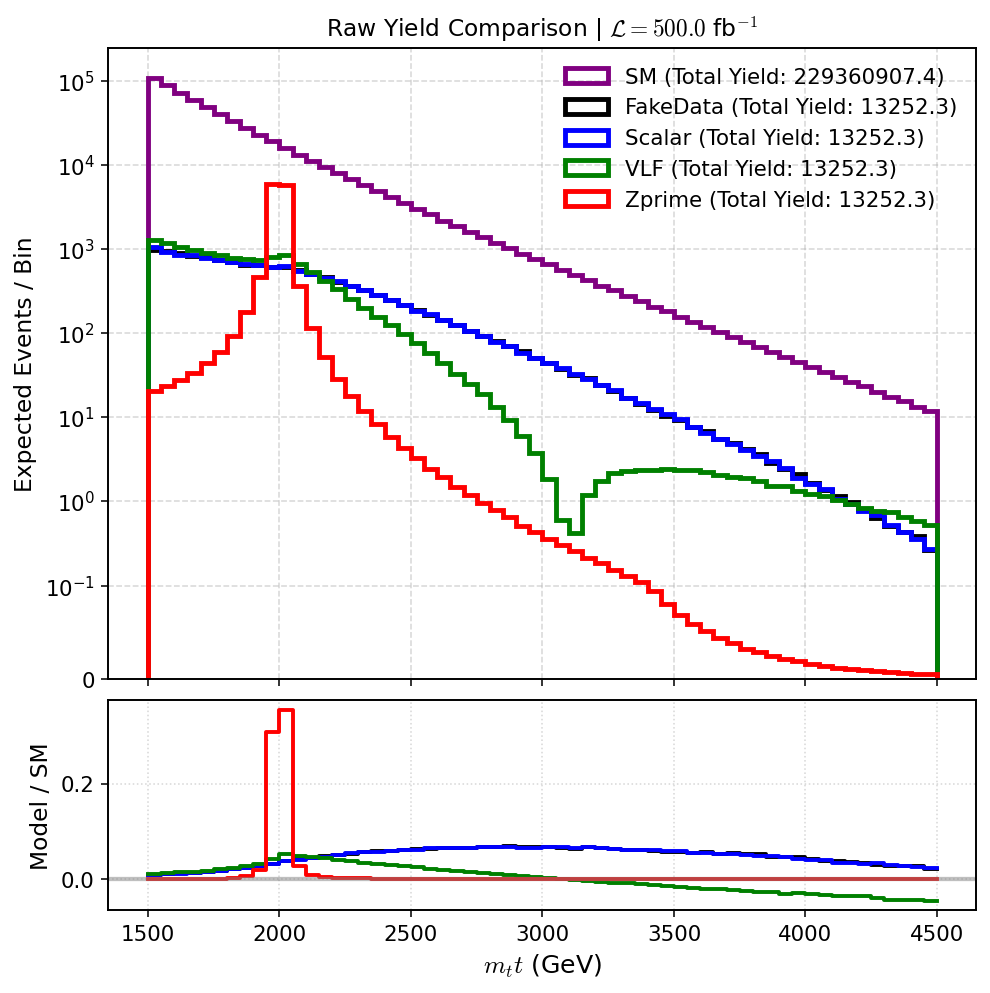

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_raw_weighted_histograms(df_bsm, df_sm, var, lum=500.0, bins=60, rng=None, density=False):
    """
    Plots superimposed 1D distributions (Main) and their ratio to SM (Sub-panel).
    Distributions are plotted with their raw expected yields for the given luminosity.
    Negative weights (e.g., from NLO interference) are fully preserved.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", "Scalar", "VLF", "Zprime"]

    # --- Define Color Mapping Here ---
    color_map = {
        'SM': 'purple',
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'FakeData': 'black'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    # Define explicit bin edges
    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    hist_data = {}

    # Extract and Bin SM (Removed np.abs to preserve negative interference)
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0
    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm, density=density)
    hist_data['SM'] = {'h': h_sm, 'lbl': f"SM (Total Yield: {np.sum(w_sm):.1f})"}

    # Extract and Bin BSM Models
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h, _ = np.histogram(x, bins=bin_edges, weights=w, density=density)
        hist_data[lab_str] = {'h': h, 'lbl': f"{lab_str} (Total Yield: {np.sum(h):.1f})"}

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    # Plot lines and their ratios
    for lab_str, data in hist_data.items():

        # Get the assigned color, defaulting to 'gray' if not found
        c = color_map.get(lab_str, 'gray')

        # Plot the main step histogram with the explicit color
        n, _, patches = ax_main.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                                     histtype="step", linewidth=2.5, label=data['lbl'], color=c)

        # Compute and plot the ratio to SM
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(h_sm > 0, data['h'] / h_sm, np.nan)

        ratio_padded = np.append(ratio, ratio[-1])
        if lab_str != 'SM':
          ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=2.0, color=c)

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    # Main Axes
    ax_main.set_title(rf"Raw Yield Comparison | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$", fontsize=12)
    ax_main.set_ylabel("Density" if density else "Expected Events / Bin", fontsize=12)
    ax_main.legend(loc="best", framealpha=1.0)

    # Use symlog so negative bins don't break the logarithmic view
    ax_main.set_yscale('symlog', linthresh=1e-1)
    ax_main.grid(True, linestyle='--', alpha=0.5)

    # Ratio Axes
    ax_ratio.axhline(0.0, color='gray', linestyle='-', alpha=0.5) # Added a zero-line to easily spot negative ratios
    ax_ratio.set_xlabel(rf'${var}$ (GeV)' if var == 'm_tt' else var, fontsize=13)
    ax_ratio.set_ylabel("Model / SM", fontsize=12)
    ax_ratio.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------
observables = [
    ("m_tt", (300, 5000)),
]

LUMI = 500.0

for v, rng in observables:
    plot_raw_weighted_histograms(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        lum=LUMI,
        bins=60,
        rng=(1500,4500),
        density=False
    )

In [7]:
# ------------------------------------------------------------
# m_cut Scan Configuration
# ------------------------------------------------------------
labels = ["FakeData", "Scalar", "VLF", "Zprime"]
mcuts = [ 1500, 1800, 2000, 2200, 2500]
mcut_max = 4_500
bin_width = 100.0
L_target = 500.0 # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# ------------------------------------------------------------
# Luminosity Scan Configuration (Notebook)
# ------------------------------------------------------------
lumi_targets = [300., 500., 1000., 1500., 2000., 2500., 3000.]

# ------------------------------------------------------------
# Data Extraction
# ------------------------------------------------------------
var = "m_tt"  # Variable of the distributions

# Clean the DataFrames
df_sm_clean = df_sm[[var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_sm_clean = df_sm_clean[df_sm_clean[var] > 0]

df_hyp_clean = df_bsm[["label", var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_clean = df_hyp_clean[df_hyp_clean[var] > 0]

# Extract into pure NumPy dictionaries
sm_data = {
    "x": df_sm_clean[var].values,
    "w": df_sm_clean["weight"].values
}

bsm_data = {}
for lab, sub in df_hyp_clean.groupby("label"):
    lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
    if lab_str in labels:
        bsm_data[lab_str] = {
            "x": sub[var].values,
            "w": sub["weight"].values
        }

# ------------------------------------------------------------
# Load the m cut and luminosity scan data frames
# ------------------------------------------------------------
df_mcut = hp.run_fast_mcut_scan(sm_data, bsm_data, labels, mcuts=mcuts,
                                mcut_max=mcut_max, bin_width=bin_width,
                                L_target=L_target, eps_values=eps_values,
                                fake_model='FakeData')

# Run the scan once to calculate both Shape and Falloff metrics but for luminosity
df_lumi = hp.run_fast_lumi_scan(sm_data, bsm_data, labels, target_mcut=1500, mcut_max=4500,
                                bin_width=100.0, lumi_targets=lumi_targets, eps_values=eps_values,
                                fake_model='FakeData')


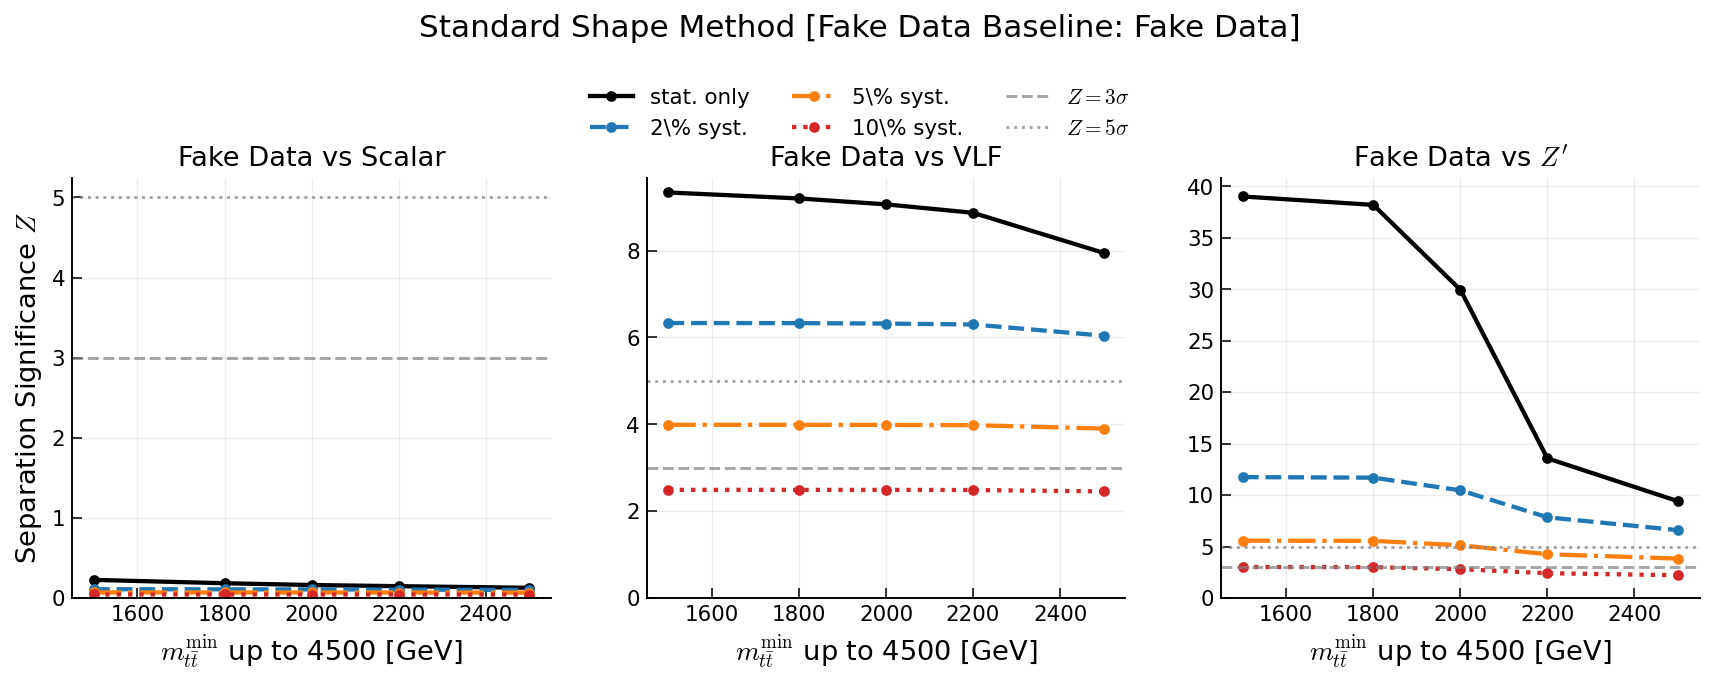

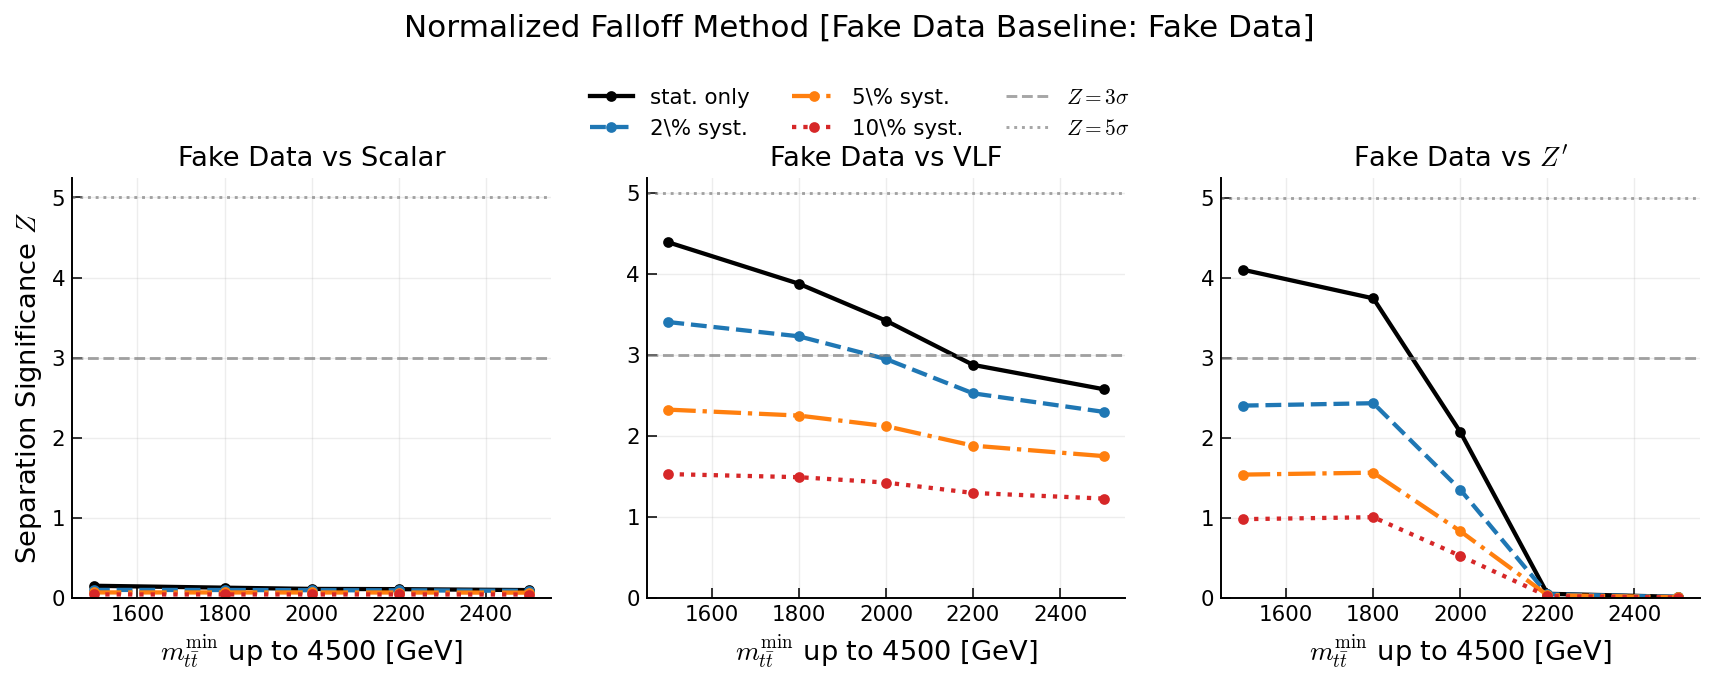

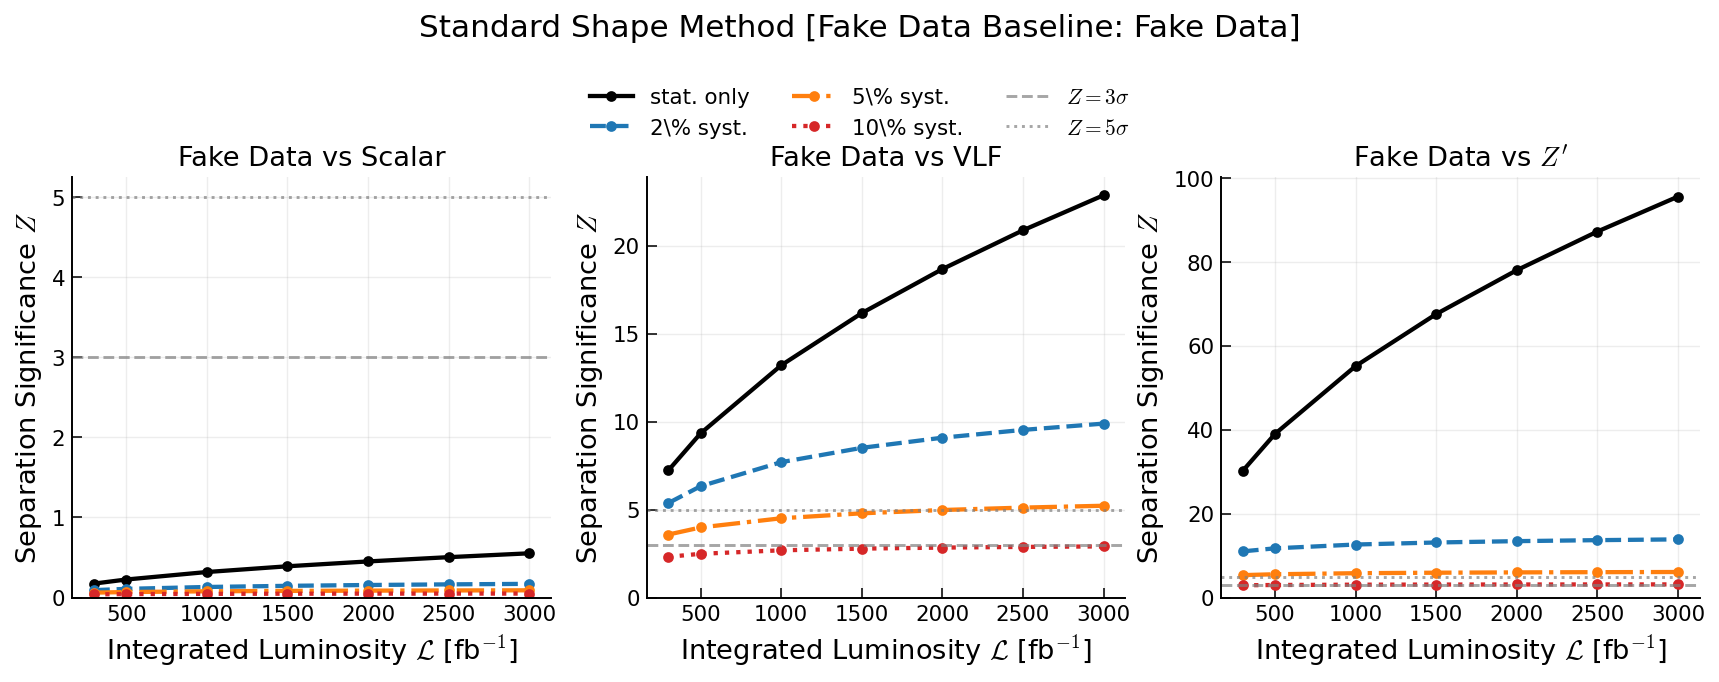

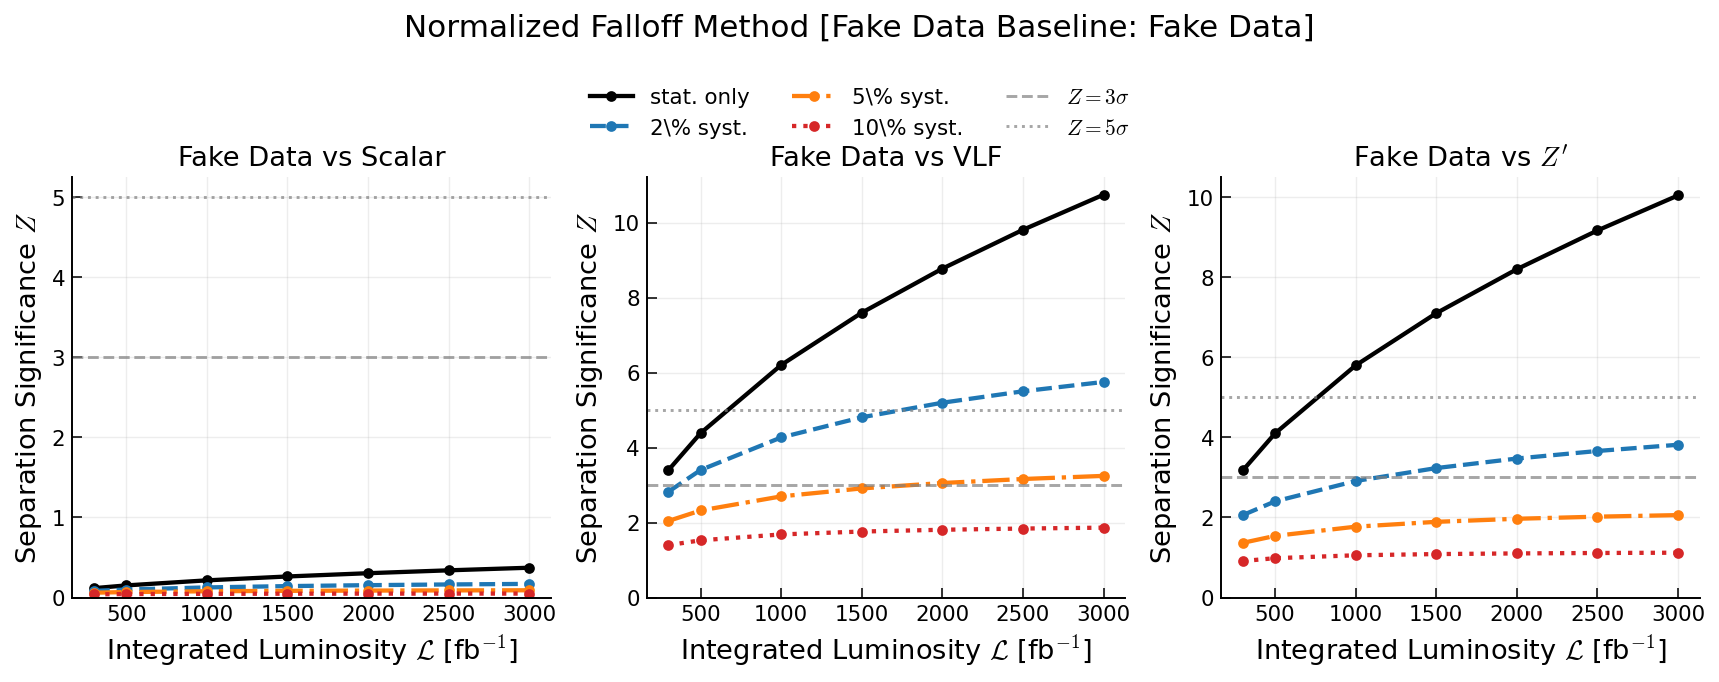

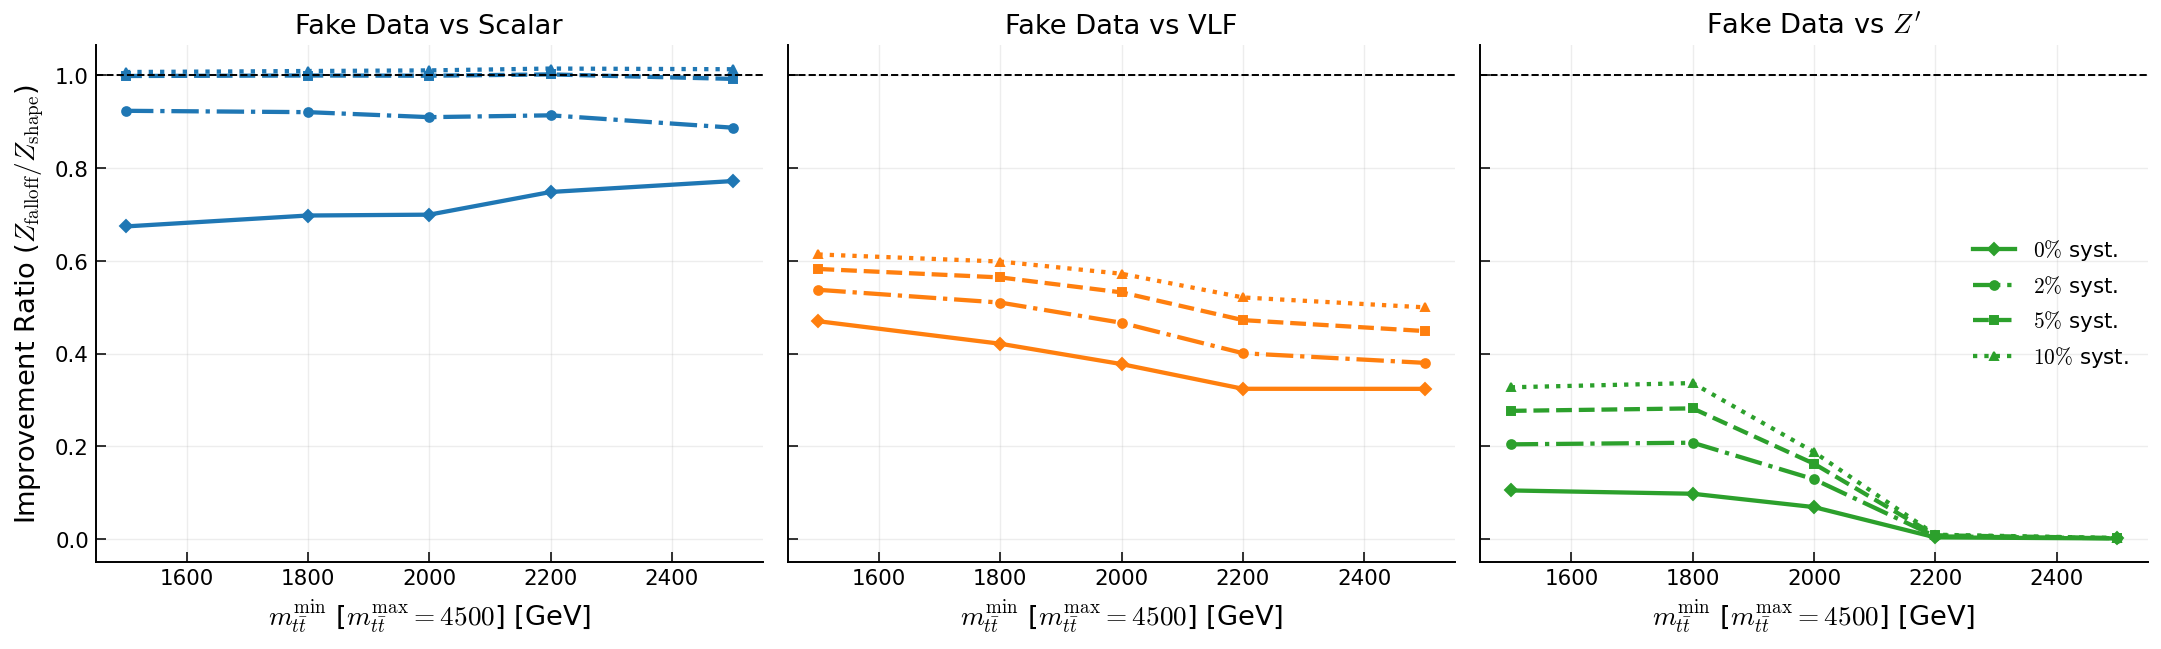

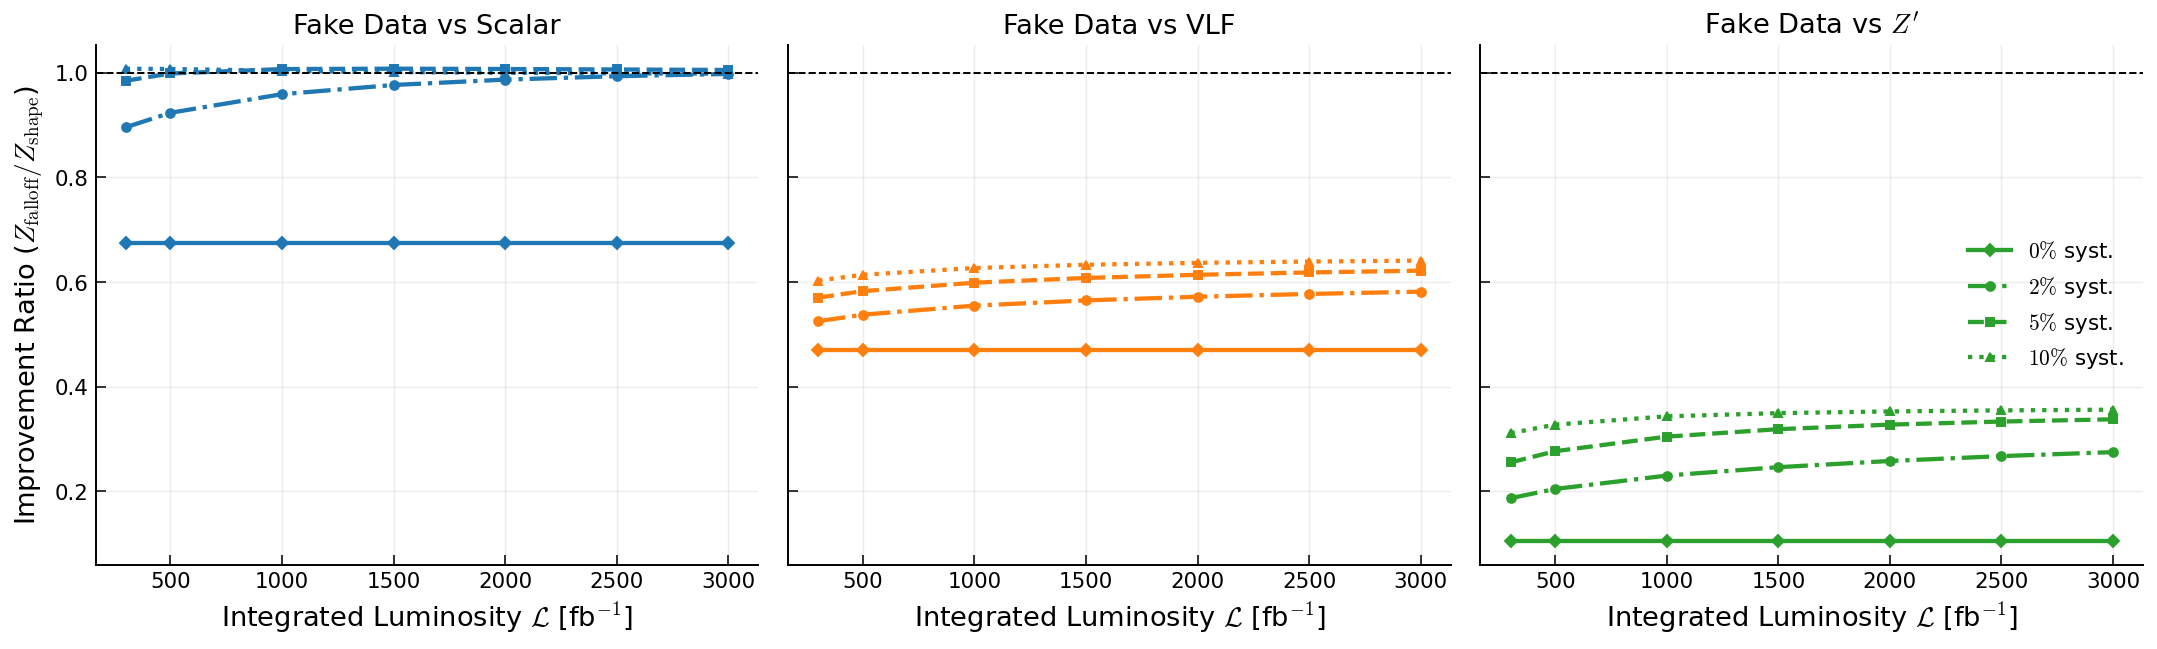

In [8]:
# Create output directory
outdir = Path("paper_plots_systematics")
outdir.mkdir(parents=True, exist_ok=True)

#  Plot Mass Cut Scans
hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="sh",
                       outfile=outdir / "syst_grid_mcut_shape.pdf",
                       fake_model='FakeData')

hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="fa",
                       outfile=outdir / "syst_grid_mcut_falloff.pdf",
                       fake_model='FakeData')

# Plot Luminosity Scans
hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="sh",
                       outfile=outdir / "syst_grid_lumi_shape.pdf",
                       shareY = False, fake_model='FakeData')

hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="fa",
                       outfile=outdir / "syst_grid_lumi_falloff.pdf",
                       shareY= False, fake_model='FakeData')


hp.plot_ratio_pairwise(df_mcut, mcut_max, eps_values,
                       outfile=outdir / "improvement_ratio_mcut.pdf")

hp.plot_ratio_pairwise_lumi(df_lumi, target_mcut=1500, eps_values=eps_values,
                            outfile=outdir / "improvement_ratio_lumi.pdf")


# Fallof Analysis

$$Z_{\rm falloff}^2
\;\approx\;
\sum_k
\frac{\left(N\,\widehat{\Delta}_i(k)-N\,\widehat{\Delta}_j(k)\right)^2}
{\sigma_{\rm ref}^2},
\qquad
n_k^{\rm ref}=\frac{N}{2}\left(|\widehat{\Delta}_i(k)|+|\widehat{\Delta}_j(k)|\right)$$

To compute $\sigma_{\rm ref}^2$, notice that since:

$$\Delta_i^{(m_{t\bar t}^{\min})}(k) =
\frac{n_{i,k}-n_{{\rm SM},k}}{n_{{\rm SM},k}} $$

The variance of $\Delta_i^{(m_{t\bar t}^{\min})}(k)$ is:

$$\sigma_\Delta^2 = \frac{n_{i,k}}{n_{SM,k}^2} + \frac{n_{i,k}^2\varepsilon^2}{ n_{SM,k}^2} = \frac{n_{i,k}}{n_{SM,k}^2}\left(1 + n_{i,k}\varepsilon^2\right)$$

To compute $\widehat{\Delta}_i^{(m_{t\bar t}^{\min})}(k)$ we used:

$$\widehat{\Delta}_i^{(m_{t\bar t}^{\min})}(k) = \frac{\Delta_i^{(m_{t\bar t}^{\min})}(k)}
{\sum_\ell \left|\Delta_i^{(m_{t\bar t}^{\min})}(\ell)\right|}$$

To simplify the notation, consider $S = \sum_\ell \left|\Delta_i^{(m_{t\bar t}^{\min})}(\ell)\right|$.

Therefore, the variance of $\widehat{\Delta}_i^{(m_{t\bar t}^{\min})}(k)$ is:

$$\sigma_{\hat{\Delta}_i}^2 = \sum_j \left( \frac{\partial \widehat{\Delta}_i}{\partial \Delta_j} \right)^2 \sigma_{\Delta_j}^2 = \left( \frac{\partial \widehat{\Delta}_i}{\partial \Delta_i} \right)^2 \sigma_{\Delta_i}^2 + \sum_{j\neq i} \left( \frac{\partial \widehat{\Delta}_i}{\partial \Delta_j} \right)^2 \sigma_{\Delta_j}^2$$

 The derivative with respect to a different bin ($j \neq i$):

 $$\frac{\partial \widehat{\Delta}_i}{\partial \Delta_j} = \Delta_k \frac{\partial}{\partial \Delta_j} (S^{-1}) = -\frac{\Delta_i}{S^2} \frac{\partial S}{\partial \Delta_j} = -\frac{\Delta_i \text{sgn}(\Delta_j)}{S^2}$$
$$\implies \left( \frac{\partial \widehat{\Delta}_k}{\partial \Delta_j} \right)^2 = \frac{\Delta_k^2 \text{sgn}^2(\Delta_j)}{S^4} = \frac{\Delta_k^2}{S^4}$$(
  
   The derivative with respect to the same bin ($j = i$):
   
   $$\frac{\partial \widehat{\Delta}_i}{\partial \Delta_i} = \frac{1 \cdot S - \Delta_i \cdot \text{sgn}(\Delta_i)}{S^2} = \frac{1}{S} - \frac{|\Delta_i|}{S^2}$$
   $$\implies \left( \frac{\partial \widehat{\Delta}_i}{\partial \Delta_i} \right)^2 = \frac{1}{S^2} - \frac{2|\Delta_i|}{S^3} + \frac{\Delta_i^2}{S^4}$$
   
   Combining the Terms:
   
   $$\sigma_{\hat{\Delta}_i}^2 = \left[ \frac{1}{S^2} - \frac{2|\Delta_i|}{S^3} + \frac{\Delta_i^2}{S^4} \right] \sigma_{\Delta_i}^2 + \sum_{j \neq i} \left[ \frac{\Delta_i^2}{S^4} \right] \sigma_{\Delta_j}^2$$
   $$\sigma_{\hat{\Delta}_i}^2 = \left[ \frac{1}{S^2} - \frac{2|\Delta_i|}{S^3}  \right] \sigma_{\Delta_i}^2 + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \sigma_{\Delta_j}^2$$
   $$\sigma_{\hat{\Delta}_{i,k}}^2 = \left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{n_{i,k}}{n_{SM,k}^2}\left(1 + n_{i,k}\varepsilon^2\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{n_{i,j}}{n_{SM,j}^2}\left(1 + n_{i,j}\varepsilon^2\right)$$

For a given luminosity $\mathcal{L}$, $n_{i,k} = \mathcal{L} x_{i,k}$:
$$\sigma_{\hat{\Delta}_{i,k}}^2 = \left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{x_{i,k}}{x_{SM,k}^2}\left(\frac{1}{\mathcal{L}} + x_{i,k}\varepsilon^2\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{x_{i,j}}{x_{SM,j}^2}\left(\frac{1}{\mathcal{L}} + x_{i,j}\varepsilon^2\right)$$


Recall that the definition of $n_{ref}(k)$ is:

$$n_k^{\rm ref}=\frac{N}{2}\left(|\widehat{\Delta}_i(k)|+|\widehat{\Delta}_j(k)|\right)$$

Therefore:
$$\sigma_{n_k^{\rm ref}} = \sqrt{\left(\frac{\partial n_k^{\rm ref}}{\partial \widehat{\Delta}_i(k)}\right)^2\sigma_{\widehat{\Delta}_i(k)}^2 +\left(\frac{\partial n_k^{\rm ref}}{\partial \widehat{\Delta}_j(k)}\right)^2 \sigma_{\widehat{\Delta}_j(k)}^2}$$
$$\sigma_{n_k^{\rm ref}} = \frac{N}{2}\sqrt{\left(\frac{\partial \vert\widehat{\Delta}_i(k)\vert}{\partial \widehat{\Delta}_i(k)}\right)^2 \sigma_{\widehat{\Delta}_i(k)}^2 + \left(\frac{\partial \vert\widehat{\Delta}_j(k)\vert}{\partial \widehat{\Delta}_j(k)}\right)^2 \sigma_{\widehat{\Delta}_j(k)}^2}$$
$$\sigma_{n_k^{\rm ref}} = \frac{N}{2}\sqrt{ \sigma_{\widehat{\Delta}_i(k)}^2 + \sigma_{\widehat{\Delta}_j(k)}^2}$$

Notice that:

$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} = \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{n_{i,k}}{n_{SM,k}^2}\left(1 + n_{i,k}\varepsilon^2\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{n_{i,j}}{n_{SM,j}^2}\left(1 + n_{i,j}\varepsilon^2\right)}{n_{ref} + \varepsilon^2 n_{ref}}$$
$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} \approx \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{n_{i,k}}{n_{SM,k}^2}\left(1 + n_{i,k}\varepsilon^2\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{n_{i,j}}{n_{SM,j}^2}\left(1 + n_{i,j}\varepsilon^2\right)}{n^{ref}_{shape}+ \varepsilon^2 n^{ref}_{shape}}$$
$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} \approx \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{n_{i,k}}{n_{SM,k}^2}\left(1 + n_{i,k}\varepsilon^2\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{n_{i,j}}{n_{SM,j}^2}\left(1 + n_{i,j}\varepsilon^2\right)}{ \varepsilon^2 (n^{ref}_{shape})^2}$$
$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} \approx \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{x_{i,k}}{x_{SM,k}^2}\left(\frac{1}{\mathcal{L}\varepsilon^2} + x_{i,k}\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{x_{i,j}}{x_{SM,j}^2}\left(\frac{1}{\mathcal{L}\varepsilon^2} + x_{i,j}\right)}{ \mathcal{L}^2(x^{ref}_{shape})^2}$$
$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} \approx \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{x_{i,k}}{\mathcal{L}^2x_{SM,k}^2}\left(\frac{1}{\mathcal{L}\varepsilon^2} + x_{i,k}\right) + \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{x_{i,j}}{\mathcal{L}^2x_{SM,j}^2}\left(\frac{1}{\mathcal{L}\varepsilon^2} + x_{i,j}\right)}{ (x^{ref}_{shape})^2}$$

For the stats only:
$$\frac{\sigma_{\hat{\Delta}_i}^2}{\sigma^2_{shape}} = \frac{\left[ \frac{1}{S^2} - \frac{2|\Delta_{i,k}|}{S^3}  \right] \frac{n_{i,k}}{n_{SM,k}^2}+ \left[ \frac{\Delta_i^2}{S^4} \right]\sum_{j }  \frac{n_{i,j}}{n_{SM,j}^2}}{n_{ref} }$$

## The cell below contains the Asimov significance as a function of the $m_{t\bar{t}}$ cut

# Why does worse systematical errors lead to better performance of the Fallof in relation to the shape

## The next cell contains the plots of the Fallof numerator and denominator bin-by-bin contribution, the Shape numerator and denominator bin-by-bin contribution the ratios of Falloff and shape numerators and denominators

## We can see that the Falloff method has a different behavior because of a dominance of statistical errors depending on the value of $\varepsilon$. To see it clearly, we can plot the variance of each method splitting the statistical and systematical contributions to it.
## We observe that the statistical variance in the fallof method dominates in the peak region for $\varepsilon = 2\%$, are of the same order in the peak region for $\varepsilon = 5\%$ an it is subdominant for $\varepsilon = 10\%$.
## In the shape method the statistical variance dominates only for $m_{t\bar{t}}\simeq 2750, \,3000 \text{ and }4000$ GeV for $\varepsilon= 2\%, \,5\% \text{ and }10\%$, respectively.
## There for, while the variance of the shape always increase with the systematical error in the region of the peak, the falloff variance barely change for $\varepsilon = 2\%$ and $5\%$ around the peak. Also, the dominance of the statistical error at the tail, in the fallof method, occurs a little bit later than the shape.

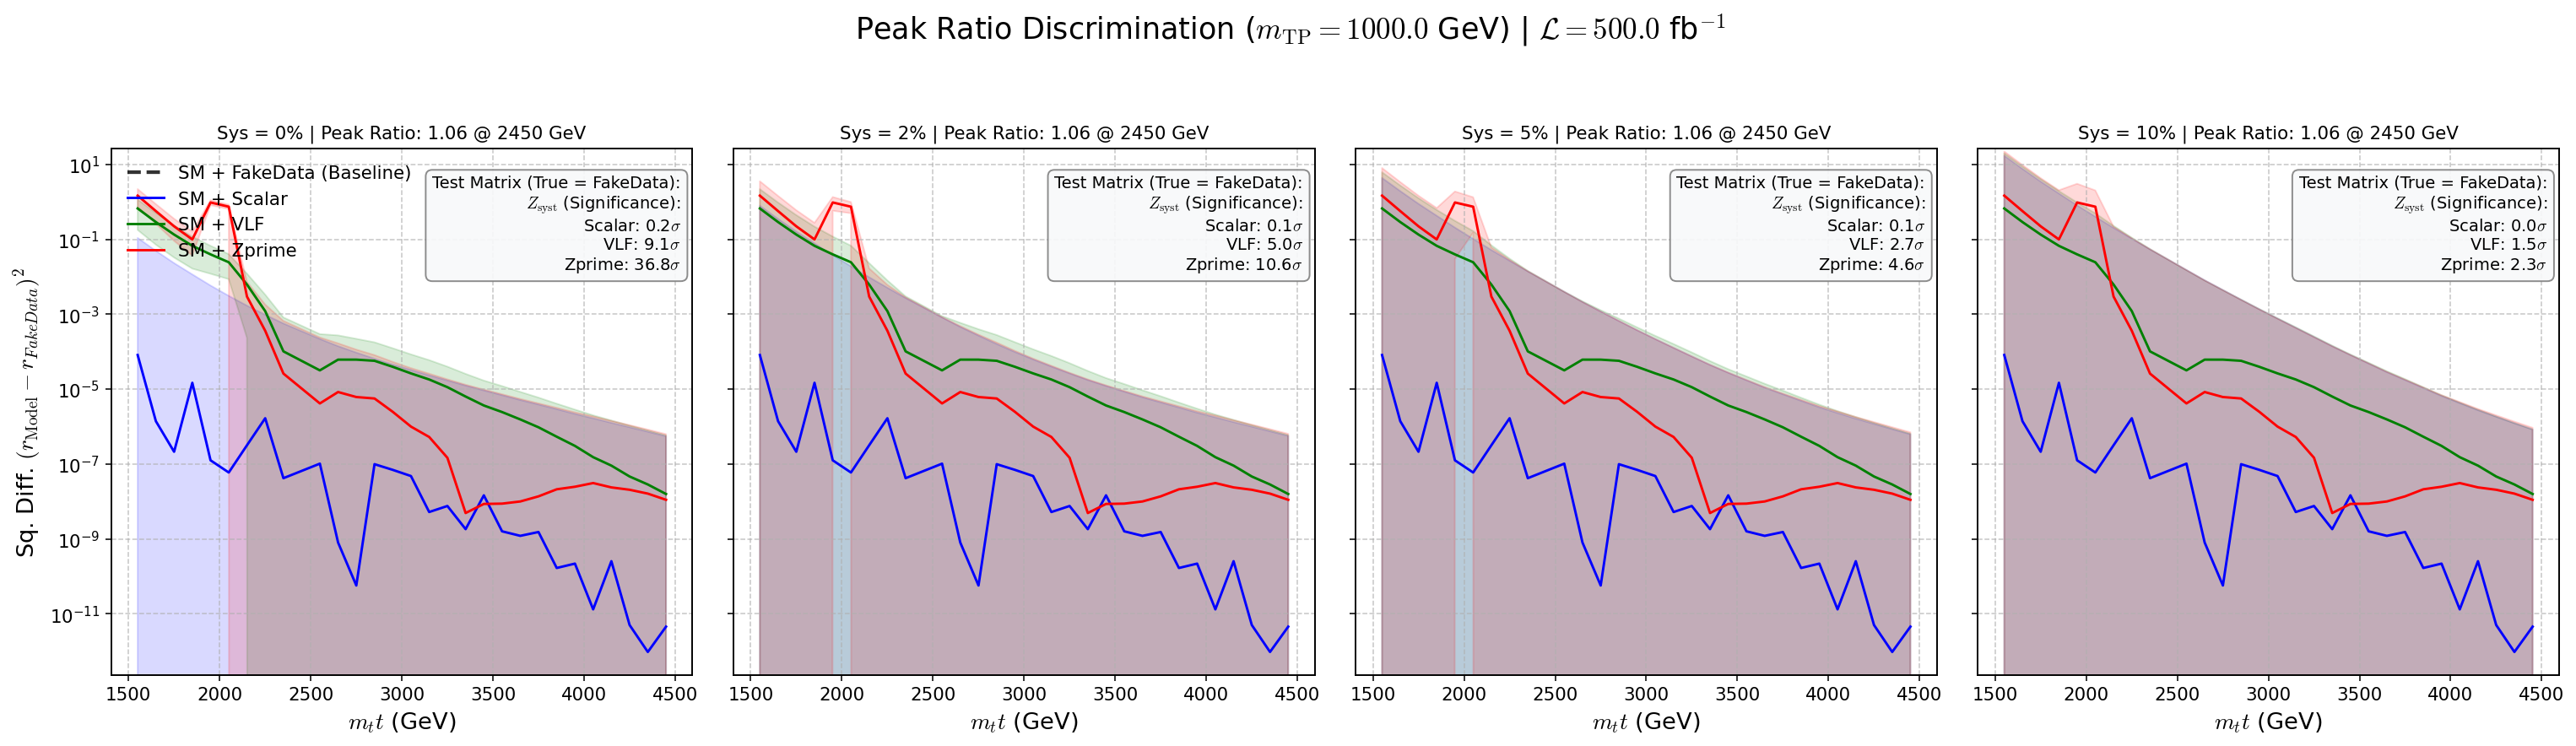


--- Significance Dictionary Exported ---
Saved successfully to: post_peak_ratios_significances.npz


In [9]:
def post_peak_ratio_sys_scan(df_sm, df_bsm, target_models=["FakeData", "Scalar", "VLF", "Zprime"],
                             var="m_tt", mTP=1000.0, lum=500.0,
                             bins=60, rng=(1500, 4500),
                             peak_search_rng=(1500, 2500),
                             asimov_model='FakeData',
                             n_bp=17, n_ap=26, sm_sys_err_list=[0.0, 0.02, 0.05, 0.10],
                             out_filename='post_peak_ratios_significances.npz'):
    """
    Scans over systematic uncertainties. Finds the peak dynamically via the max Data/SM ratio.
    Computes post-peak ratios, evaluates the Covariance Matrices, and plots the
    SQUARED absolute differences (Model - Baseline)^2 with robust second-order error bands.
    """
    def get_cols(df):
        l_col = "label" if "label" in df.columns else "model"
        w_col = "weight" if "weight" in df.columns else "w_norm"
        return l_col, w_col

    bin_edges = np.arange(rng[0], rng[1] + 100, 100)
    bin_centers_full = bin_edges[:-1] + np.diff(bin_edges)/2
    sys_q_dict = {}

    # ==========================================
    # Extract Base Histograms
    # ==========================================
    lbl_sm, wgt_sm = get_cols(df_sm)
    df_sm_clean = df_sm[[lbl_sm, var, wgt_sm]].replace([np.inf, -np.inf], np.nan).dropna()
    x_sm = df_sm_clean[var].values
    w_sm = df_sm_clean[wgt_sm].values * lum * 1000.0

    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm)
    var_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    lbl_bsm, wgt_bsm = get_cols(df_bsm)
    df_bsm_clean = df_bsm[[lbl_bsm, var, wgt_bsm]].replace([np.inf, -np.inf], np.nan).dropna()

    raw_signals = {}
    for sig in target_models:
        sig_df = df_bsm_clean[df_bsm_clean[lbl_bsm].astype(str) == sig]
        if not sig_df.empty:
            x_sig = sig_df[var].values
            w_sig = sig_df[wgt_bsm].values * lum * 1000.0
            h_sig, _ = np.histogram(x_sig, bins=bin_edges, weights=w_sig)
            v_sig, _ = np.histogram(x_sig, bins=bin_edges, weights=w_sig**2)
            raw_signals[sig] = {'h_sig': h_sig, 'v_sig': v_sig}

    if asimov_model not in raw_signals:
        raise ValueError(f"Asimov baseline model '{asimov_model}' not found in df_bsm.")

    model_significances = {}
    x_centers_dict = {}
    fig, axes = plt.subplots(1, len(sm_sys_err_list), figsize=(5.5 * len(sm_sys_err_list), 6), sharey=True)
    axes = np.atleast_1d(axes)

    # ==========================================
    # Loop Over Systematic Errors
    # ==========================================
    for idx, sys_err in enumerate(sm_sys_err_list):
        ax = axes[idx]

        hypotheses = {}
        for sig, data in raw_signals.items():
            h_tot = h_sm + data['h_sig']
            err_tot = np.sqrt(var_sm + data['v_sig'] + (sys_err * h_sm)**2)
            hypotheses[sig] = {'h': h_tot, 'err': err_tot}

        h_asimov = hypotheses[asimov_model]['h']
        excess_ratio = np.divide(h_asimov, h_sm, out=np.zeros_like(h_asimov), where=h_sm > 0)

        range_mask = (bin_centers_full >= peak_search_rng[0]) & (bin_centers_full <= peak_search_rng[1])
        valid_mask = range_mask & (h_sm > 0)

        valid_indices = np.where(valid_mask)[0]
        if len(valid_indices) == 0:
             raise ValueError(f"No valid bins with SM > 0 found in the range {peak_search_rng}.")

        b_peak = valid_indices[np.argmax(excess_ratio[valid_indices])]

        start_idx = max(0, b_peak - n_bp)
        end_idx = min(len(bin_edges)-1, b_peak + n_ap)
        peak_local_idx = b_peak - start_idx
        x_centers = bin_centers_full[start_idx:end_idx]
        x_centers_dict[sys_err] = x_centers

        ratios_dict = {}
        for name, data in hypotheses.items():
            h, herr = data['h'], data['err']
            aux, err = [], []
            for j in range(start_idx, end_idx):
                A, B = h[j], h[b_peak]
                errA, errB = herr[j], herr[b_peak]
                val = A / B if B > 0 else 0
                aux.append(val)
                safe_err = val * np.sqrt((errA / A)**2 + (errB / B)**2) if (A > 0 and B > 0) else 0.0
                err.append(safe_err)
            ratios_dict[name] = {'r': np.array(aux), 'err': np.array(err)}

        r_A = ratios_dict[asimov_model]['r']
        stats_mask = np.arange(len(r_A)) != peak_local_idx
        valid_r_A = r_A[stats_mask]
        N_eval = len(valid_r_A)

        stats_lines = [
            rf"Test Matrix (True = {asimov_model}):",
            r"$Z_{\mathrm{syst}}$ (Significance):"
        ]
        q_dict = {}
        sym_err_dict = {}

        for name in hypotheses.keys():
            q_name_dict = {}
            if name == asimov_model:
                continue

            r_B = ratios_dict[name]['r'][stats_mask]

            n_B = hypotheses[name]['h'][start_idx:end_idx][stats_mask]
            n_peak_B = hypotheses[name]['h'][b_peak]

            n_ref = n_B
            n_peak_ref = n_peak_B
            r_ref = r_B

            C_ref = np.zeros((N_eval, N_eval))
            eps = sys_err

            peak_var_term = (1.0 + (eps**2) * n_peak_ref) / n_peak_ref if n_peak_ref > 0 else 0.0

            for i in range(N_eval):
                for j in range(N_eval):
                    if i == j:
                        bin_var_term = (1.0 + (eps**2) * n_ref[i]) / n_ref[i] if n_ref[i] > 0 else 0.0
                        C_ref[i, j] = (r_ref[i]**2) * (bin_var_term + peak_var_term)
                    else:
                        C_ref[i, j] = r_ref[i] * r_ref[j] * peak_var_term

            try:
                C_inv = np.linalg.inv(C_ref)
            except np.linalg.LinAlgError:
                C_inv = np.diag(1.0 / np.diag(C_ref))

            sym_err_dict[name] = np.sqrt(np.diag(C_ref))

            delta_r = valid_r_A - r_B
            q_name_dict['num'] = delta_r
            q_name_dict['denom'] = np.diag(np.diag(C_inv))
            q_name_dict['offd'] = C_inv - np.diag(np.diag(C_inv))

            q_A = delta_r.T @ C_inv @ delta_r
            Z_score = max(np.sqrt(q_A), 0.0)
            q_dict[name] = q_name_dict

            if name not in model_significances:
                model_significances[name] = {}
            model_significances[name][sys_err] = {
                'sqrt_chi2': Z_score,
                'z_score': Z_score
            }

            stats_lines.append(rf"{name}: {Z_score:.1f}$\sigma$")

        sys_q_dict[sys_err] = q_dict

        # ==========================================
        # Fill Subplot
        # ==========================================
        colors = {'FakeData': 'black', 'Scalar': 'blue', 'VLF': 'green', 'Zprime': 'red'}

        r_base = ratios_dict[asimov_model]['r']
        y_min_plot, y_max_plot = 0.0, 0.0001

        for name in hypotheses.keys():
            lbl = f"SM + {name}"
            c = colors.get(name, 'magenta')

            if name == asimov_model:
                ax.axhline(0.0, color='k', linestyle='--', alpha=0.8, zorder=4, label=f"{lbl} (Baseline)")
            else:
                x_plot = x_centers[stats_mask]
                r_base_plot = r_base[stats_mask]
                r_model_plot = ratios_dict[name]['r'][stats_mask]

                # Calculate raw difference
                raw_diff = r_model_plot - r_base_plot

                # Calculate Squared Difference (Model - Baseline)^2
                y_val = raw_diff**2
                ax.plot(x_plot, y_val, label=lbl, color=c, markersize=4, linewidth=1.5, zorder=3)

                # Propagate error robustly for Z = Y^2
                # Var(Z) = 4 * Y^2 * Var(Y) + 2 * (Var(Y))^2
                y_err = sym_err_dict[name]
                z_err = np.sqrt(4 * (raw_diff**2) * (y_err**2) + 2 * (y_err**4))

                ax.fill_between(x_plot, y_val - z_err, y_val + z_err, color=c, alpha=0.15, zorder=1)

                valid_y = y_val[np.isfinite(y_val)]
                if len(valid_y) > 0:
                    y_max_plot = max(y_max_plot, np.max(valid_y))

                valid_err_top = (y_val + z_err)[np.isfinite(z_err)]
                if len(valid_err_top) > 0:
                    y_max_plot = max(y_max_plot, np.max(valid_err_top))

        ax.set_xlabel(rf'${var}$ (GeV)', fontsize=14)
        ax.set_yscale('log')
        if idx == 0:
            ax.set_ylabel(rf'Sq. Diff. $(r_{{\mathrm{{Model}}}} - r_{{{asimov_model}}})^2$', fontsize=14)

        chosen_peak_mass = bin_centers_full[b_peak]
        max_ratio_val = excess_ratio[b_peak]
        ax.set_title(rf'Sys = {sys_err * 100:.0f}% | Peak Ratio: {max_ratio_val:.2f} @ {chosen_peak_mass:.0f} GeV', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.7)

        y_range = y_max_plot
        ax.set_ylim(- (y_range * 0.05), y_max_plot + (y_range * 0.2))

        if idx == 0:
            ax.legend(fontsize=11, framealpha=1.0, loc='upper left')

        stats_text = "\n".join(stats_lines)
        ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))

    # ==========================================
    # FINALIZATION
    # ==========================================
    fig.suptitle(rf'Peak Ratio Discrimination ($m_{{\mathrm{{TP}}}} = {mTP}$ GeV) | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$', fontsize=18, y=1.05)
    plt.tight_layout()
    plt.savefig('Squared_Difference_Curves_Sys_Scan.pdf', bbox_inches='tight')
    plt.show()

    print("\n--- Significance Dictionary Exported ---")
    np.savez(out_filename, results=model_significances)
    print(f"Saved successfully to: {out_filename}")

    return x_centers_dict, sys_q_dict
# ============================================================
# Execution Example
# ============================================================
x_centers, sys_q_dict = post_peak_ratio_sys_scan(
     df_sm=df_sm,
     df_bsm=df_bsm,
     target_models=["FakeData", "Scalar", "VLF", "Zprime"],
     var="m_tt",
     mTP=1000.0,
     lum=500.0,
     bins=60,
     rng=(1500, 4500),
     asimov_model='FakeData',
     n_bp=18,
     n_ap=27,
     sm_sys_err_list=[0.0, 0.02, 0.05, 0.10],
     out_filename='post_peak_ratios_significances.npz'
)

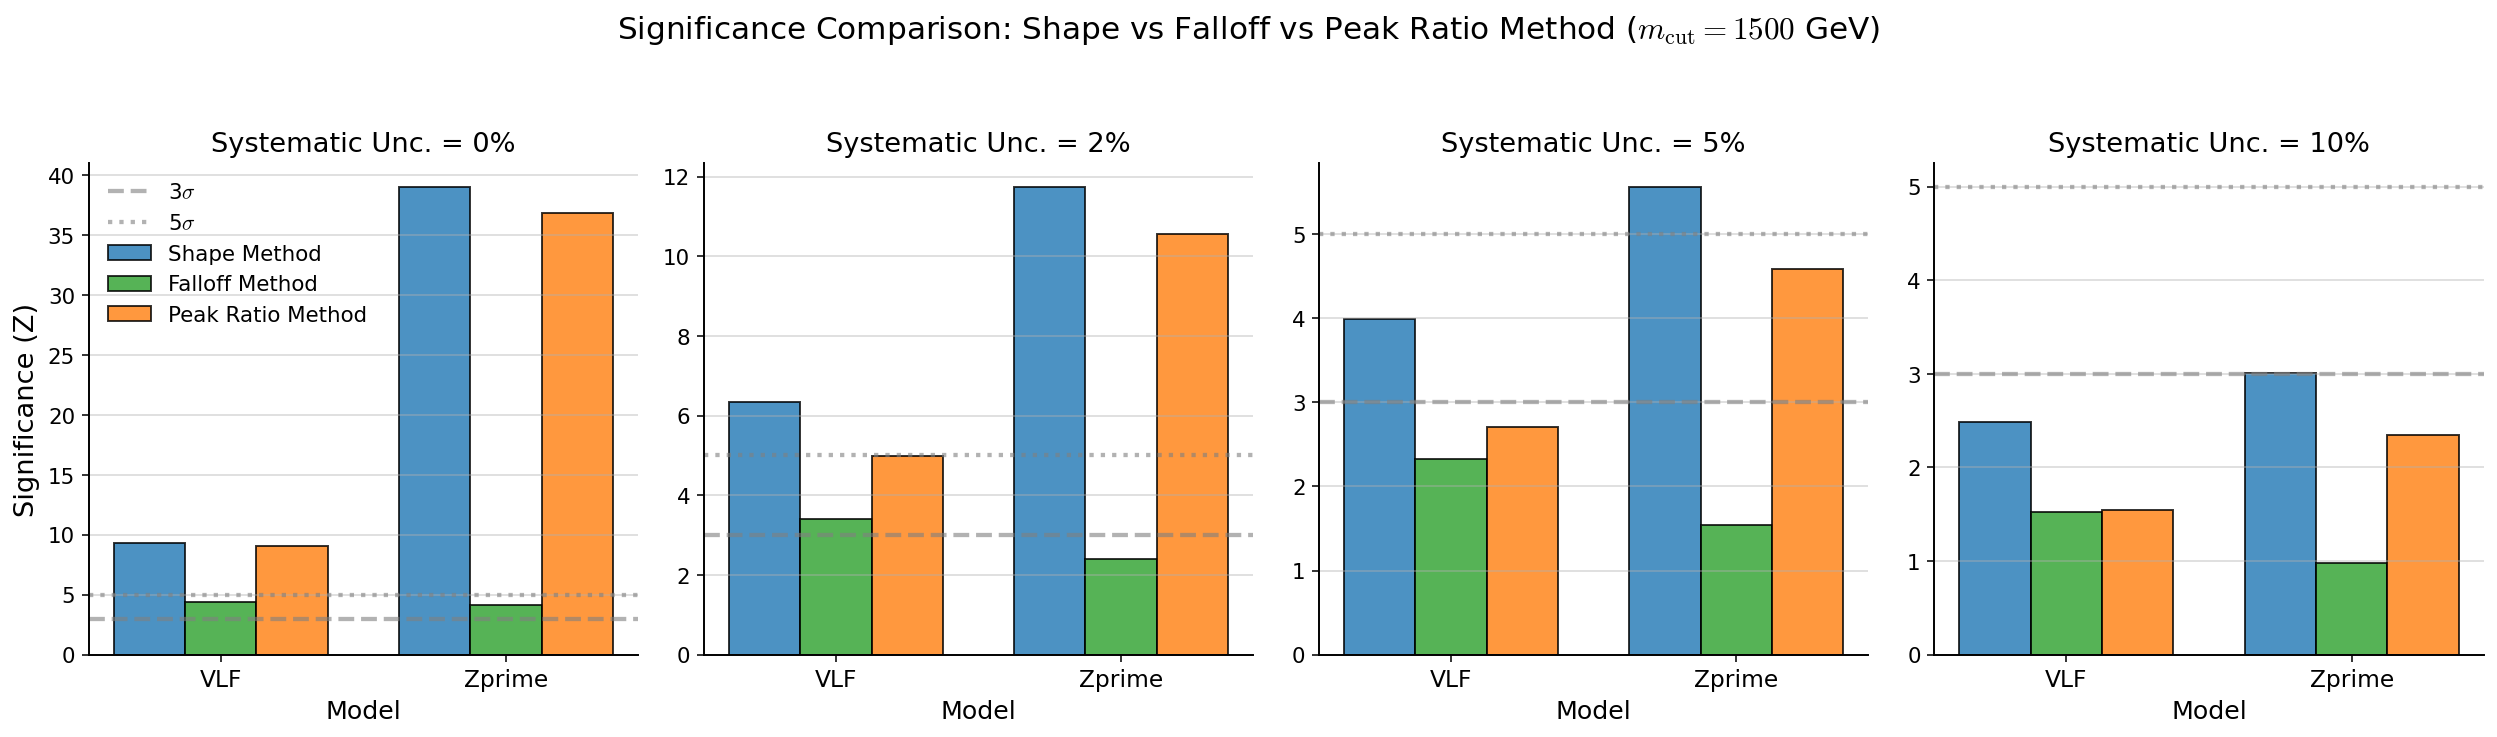

In [10]:
# -------------------------------------------------------------------
# Configuration & Data Loading
# -------------------------------------------------------------------
dict_path = './post_peak_ratios_significances.npz'

# Load the dictionary securely.
loaded_data = np.load(dict_path, allow_pickle=True)
if 'results' in loaded_data:
    post_peak_dict = loaded_data['results'].item()
else:
    post_peak_dict = {k: loaded_data[k].item() for k in loaded_data.files}

# Define the pairings and the X-axis labels
target_mcut = 1500

# FIXED: Update to the new 'FakeData vs Model' naming convention used in df_mcut
pairs = ['FakeData vs VLF', 'FakeData vs Zprime']
x_labels = ['VLF', 'Zprime'] # The second name in the comparison
eps_values = [0.0, 0.02, 0.05, 0.10]

# -------------------------------------------------------------------
# Extract and Align the Data
# -------------------------------------------------------------------
df_sub = df_mcut[df_mcut['mcut'] == target_mcut]

shape_data = {eps: [] for eps in eps_values}
falloff_data = {eps: [] for eps in eps_values}  # NEW: For Falloff Method
post_peak_data = {eps: [] for eps in eps_values}

for i, pair in enumerate(pairs):
    model = x_labels[i]
    row = df_sub[df_sub['pair'] == pair]

    # Match the model name (ignores spaces, cases, and underscores)
    matched_model_key = None
    clean_target = model.lower().replace(" ", "").replace("_", "")
    for k in post_peak_dict.keys():
        clean_k = str(k).lower().replace(" ", "").replace("_", "")
        if clean_target in clean_k:
            matched_model_key = k
            break

    if matched_model_key is None:
        print(f"WARNING: Could not find any match for model '{model}' in the dictionary!")

    for eps in eps_values:
        # Extract Shape Method Z-score
        col_name_sh = f"Z_sh_eps_{int(100*eps):02d}"
        if not row.empty and col_name_sh in row.columns:
            z_shape = row[col_name_sh].values[0]
        else:
            z_shape = 0.0
        shape_data[eps].append(z_shape)

        # Extract Falloff Method Z-score
        col_name_fa = f"Z_fa_eps_{int(100*eps):02d}"
        if not row.empty and col_name_fa in row.columns:
            z_falloff = row[col_name_fa].values[0]
        else:
            z_falloff = 0.0
        falloff_data[eps].append(z_falloff)

        # Extract Post-Peak sqrt(chi^2)
        val_post_peak = 0.0
        if matched_model_key is not None:
            model_dict = post_peak_dict[matched_model_key]
            for dict_eps, dict_vals in model_dict.items():
                if np.isclose(eps, dict_eps, atol=1e-5):
                    # Handle the nested dictionary structure
                    if isinstance(dict_vals, dict) and 'z_score' in dict_vals:
                        val_post_peak = dict_vals['z_score']
                    else:
                        #val_post_peak = dict_vals
                        print('Oh no')
                    break

        post_peak_data[eps].append(val_post_peak)

# -------------------------------------------------------------------
# Plotting the Comparison Grid
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, len(eps_values), figsize=(18, 5), sharey=False)

x_indices = np.arange(len(x_labels))

# Narrow the bar width to fit 3 bars side-by-side
bar_width = 0.25

# Custom colors for the three methods
color_shape = '#1f77b4'      # Blue
color_falloff = '#2ca02c'    # Green
color_post_peak = '#ff7f0e'  # Orange

for i, eps in enumerate(eps_values):
    ax = axes[i]

    sh_vals = shape_data[eps]
    fa_vals = falloff_data[eps]
    pp_vals = post_peak_data[eps]

    # Plot grouped bars: offset by -bar_width, 0, and +bar_width
    ax.bar(x_indices - bar_width, sh_vals, bar_width, label='Shape Method', color=color_shape, edgecolor='black', alpha=0.8)
    ax.bar(x_indices, fa_vals, bar_width, label='Falloff Method', color=color_falloff, edgecolor='black', alpha=0.8)
    ax.bar(x_indices + bar_width, pp_vals, bar_width, label='Peak Ratio Method', color=color_post_peak, edgecolor='black', alpha=0.8)

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_title(f'Systematic Unc. = {int(eps*100)}%', fontsize=14)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.set_xlabel('Model', fontsize=13)

    # Draw reference lines for 3-sigma (evidence) and 5-sigma (discovery)
    ax.axhline(3.0, color='gray', linestyle='--', alpha=0.6, label=r'3$\sigma$')
    ax.axhline(5.0, color='gray', linestyle=':', alpha=0.6, label=r'5$\sigma$')

    if i == 0:
        ax.set_ylabel('Significance (Z)', fontsize=14)
        # Deduplicate legend handles (so 3/5 sigma lines only appear once)
        handles, labels_ = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper left', frameon=False)

    # Ensure uniform scaling for easy visual comparison
    #x.set_ylim(0, 10) # Adjust this upper limit if your Z-scores are massively higher!

    ax.grid(axis='y', linestyle='-', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(rf'Significance Comparison: Shape vs Falloff vs Peak Ratio Method ($m_{{\mathrm{{cut}}}} = {target_mcut}$ GeV)', fontsize=16, y=1.05)

plt.tight_layout()
plt.savefig('Comparison_Shape_vs_Falloff_vs_PostPeak.pdf', bbox_inches='tight')
plt.show()